# 3D slice concordance (Duke Breast MRI × DINOv3 / MedDINOv3 / MRI_Core)

Hypothesis probe: do vision FM representations stay similar for nearby axial slices of the same volume?

1. Sample two random slices from the same volume (any z-gap); store as **[0, 1]** float tensors.
2. Encode with **DINOv3**, **MedDINOv3**, and **MRI_Core** (CLS + aligned-patch scores for each).
3. Relate cosine similarity to absolute z-distance.

In [11]:
from __future__ import annotations

import json
import sys
from collections import OrderedDict
from pathlib import Path
from typing import List, Optional, Tuple, Union

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

# Repo root on sys.path so `duke` imports work when the kernel cwd is src/
REPO_ROOT = Path("/common/ganesanv/tlab")
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from duke.convert import resolve_scan

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device={DEVICE}")

device=cuda


## Lightweight paired-slice dataset

Each index is a volume. `__getitem__` draws two distinct random axial slices and returns them as **[0, 1]** float tensors resized to 224×224, with label = absolute z-distance in mm. Per-encoder normalization (ImageNet for DINOv3/MedDINOv3; keep [0, 1] and upsample for MRI_Core) happens at encode time.

In [13]:
ROOT = REPO_ROOT / "data/tcia/duke_breast_cancer_processed"
IMAGE_SIZE = 224
PATCH_SIZE = 16
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


class _VolumeCache:
    """Process-local LRU of memmapped NIfTI arrays."""

    def __init__(self, maxsize: int = 4) -> None:
        self.maxsize = maxsize
        self._cache: OrderedDict[str, np.ndarray] = OrderedDict()

    def get(self, path: Path) -> np.ndarray:
        key = str(path)
        if key in self._cache:
            self._cache.move_to_end(key)
            return self._cache[key]
        data = np.asanyarray(nib.load(str(path), mmap=True).dataobj)
        self._cache[key] = data
        if len(self._cache) > self.maxsize:
            self._cache.popitem(last=False)
        return data


def _slice_to_pil(
    volume: np.ndarray,
    z: int,
    percentiles: Tuple[float, float] = (1.0, 99.0),
) -> Image.Image:
    sl = np.asarray(volume[..., z], dtype=np.float32)
    lo, hi = np.percentile(sl, percentiles)
    if hi <= lo:
        hi = lo + 1.0
    norm = np.clip((sl - lo) / (hi - lo), 0.0, 1.0)
    u8 = (norm * 255.0).astype(np.uint8)
    return Image.fromarray(u8, mode="L").convert("RGB")


def _z_distance_mm(
    z_i: int,
    z_j: int,
    slice_locations: Optional[List[float]],
    z_spacing_mm: float,
) -> float:
    if slice_locations is not None and len(slice_locations) > max(z_i, z_j):
        return float(abs(slice_locations[z_i] - slice_locations[z_j]))
    return float(abs(z_i - z_j) * abs(z_spacing_mm))


class ConcordanceSlicePairDataset(Dataset):
    """Sample two random slices from the same Duke volume; label = |Δz| in mm."""

    def __init__(
        self,
        root: Union[str, Path] = ROOT,
        *,
        scan: Union[str, int] = "pre",
        image_size: int = IMAGE_SIZE,
        pairs_per_volume: int = 1,
        volume_cache_size: int = 4,
        seed: Optional[int] = None,
        max_volumes: Optional[int] = None,
    ) -> None:
        self.root = Path(root)
        self.scan_type = resolve_scan(scan)
        self.image_size = int(image_size)
        self.pairs_per_volume = int(pairs_per_volume)
        self._seed = seed
        self._volume_cache = _VolumeCache(maxsize=volume_cache_size)

        index_path = self.root / "index" / "series_index.json"
        if not index_path.is_file():
            raise FileNotFoundError(f"Missing {index_path}")
        with open(index_path) as f:
            series_index = json.load(f)

        # (patient_id, volume_rel, meta_rel, n_slices)
        self._volumes: List[Tuple[str, str, str, int]] = []
        for series in series_index.get("series", []):
            if series["scan_type"] != self.scan_type:
                continue
            n_z = int(series["n_slices"])
            if n_z < 2:
                continue
            self._volumes.append(
                (
                    series["patient_id"],
                    series["volume_path"],
                    series["meta_path"],
                    n_z,
                )
            )

        if max_volumes is not None:
            self._volumes = self._volumes[: int(max_volumes)]

        if not self._volumes:
            raise RuntimeError(f"No volumes for scan={self.scan_type!r} under {self.root}")

        # Lazy meta cache: slice_locations + |affine z-spacing|
        self._meta_cache: dict[str, Tuple[Optional[List[float]], float]] = {}

        print(
            f"ConcordanceSlicePairDataset scan={self.scan_type} "
            f"volumes={len(self._volumes)} pairs_per_volume={self.pairs_per_volume} "
            f"len={len(self)}"
        )

    def __len__(self) -> int:
        return len(self._volumes) * self.pairs_per_volume

    def _rng(self, index: int) -> np.random.RandomState:
        if self._seed is None:
            return np.random.RandomState()
        return np.random.RandomState(self._seed + int(index))

    def _meta(self, meta_rel: str) -> Tuple[Optional[List[float]], float]:
        if meta_rel in self._meta_cache:
            return self._meta_cache[meta_rel]
        with open(self.root / meta_rel) as f:
            meta = json.load(f)
        locs = meta.get("slice_locations")
        locs = [float(x) for x in locs] if locs else None
        affine = meta.get("affine")
        z_spacing = abs(float(affine[2][2])) if affine is not None else 1.0
        if z_spacing == 0.0:
            z_spacing = 1.0
        self._meta_cache[meta_rel] = (locs, z_spacing)
        return locs, z_spacing

    def _to_tensor(self, image: Image.Image) -> torch.Tensor:
        image = TF.resize(image, [self.image_size, self.image_size], antialias=True)
        return TF.to_tensor(image)  # float [0, 1], shape (3, H, W)

    def __getitem__(self, index: int):
        vol_idx = int(index) % len(self._volumes)
        patient_id, vol_rel, meta_rel, n_z = self._volumes[vol_idx]
        rng = self._rng(index)

        z_i, z_j = rng.choice(n_z, size=2, replace=False)
        z_i, z_j = int(z_i), int(z_j)

        volume = self._volume_cache.get(self.root / vol_rel)
        img_i = self._to_tensor(_slice_to_pil(volume, z_i))
        img_j = self._to_tensor(_slice_to_pil(volume, z_j))

        locs, z_spacing = self._meta(meta_rel)
        distance = _z_distance_mm(z_i, z_j, locs, z_spacing)

        meta = {
            "patient_id": patient_id,
            "z_i": z_i,
            "z_j": z_j,
            "index_distance": abs(z_i - z_j),
        }
        return (img_i, img_j), torch.tensor(distance, dtype=torch.float32), meta


def collate_pairs(batch):
    pairs, distances, metas = zip(*batch)
    imgs_a = torch.stack([p[0] for p in pairs], dim=0)
    imgs_b = torch.stack([p[1] for p in pairs], dim=0)
    distances = torch.stack(list(distances), dim=0)
    return (imgs_a, imgs_b), distances, list(metas)

ConcordanceSlicePairDataset scan=pre volumes=8 pairs_per_volume=1 len=8
{'patient_id': 'Breast_MRI_001', 'z_i': 110, 'z_j': 112, 'index_distance': 2} Δz=2.200 mm
tensors: (3, 224, 224), (3, 224, 224)


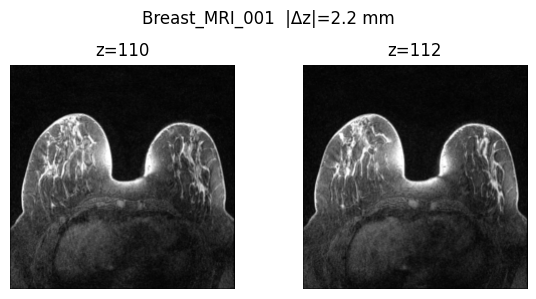

In [14]:
# Smoke-test: one pair from a small subset
ds = ConcordanceSlicePairDataset(
    ROOT,
    scan="pre",
    seed=0,
    pairs_per_volume=1,
    max_volumes=8,
)
(img_a, img_b), dist, meta = ds[0]
print(meta, f"Δz={dist.item():.3f} mm")
print(f"tensors: {tuple(img_a.shape)}, {tuple(img_b.shape)}  range=[{img_a.min():.3f}, {img_a.max():.3f}]")

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, img, title in zip(
    axes,
    (img_a, img_b),
    (f"z={meta['z_i']}", f"z={meta['z_j']}"),
):
    ax.imshow(img.permute(1, 2, 0).numpy().clip(0, 1))
    ax.set_title(title)
    ax.axis("off")
fig.suptitle(f"{meta['patient_id']}  |Δz|={dist.item():.1f} mm")
plt.tight_layout()
plt.show()

## Load encoders: DINOv3, MedDINOv3, MRI_Core

- **DINOv3 / MedDINOv3**: `forward_features` → CLS + patch tokens (ImageNet-normalized 224 inputs).
- **MRI_Core** (SAM ViT-B image encoder): `image_encoder` → spatial **patch** features `[B, C, H, W]` (kept in **[0, 1]**, resized to SAM image size, default 1024). CLS is the mean over patches; patch concordance uses the same trimmed-mean aligned-patch pipeline.

In [31]:
REPO_DIR = str(REPO_ROOT / "opt/dinov3")
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

from dinov3.models.vision_transformer import vit_base

MODEL_DINOV3_VITB = "dinov3_vitb16"
DINOV3_WEIGHTS = str(
    REPO_ROOT / "opt/dinov3-weights/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth"
)
MEDDINOV3_WEIGHTS = str(REPO_ROOT / "opt/meddinov3/model.pth")
MRI_FOUNDATION_DIR = str(REPO_ROOT / "opt/mri_foundation")
MRI_CORE_WEIGHTS = str(REPO_ROOT / "opt/mri_foundation/mri_foundation.pth")

# --- DINOv3 (natural-image pretrain) ---
dinov3 = torch.hub.load(
    REPO_DIR,
    model=MODEL_DINOV3_VITB,
    source="local",
    weights=DINOV3_WEIGHTS,
)
dinov3.to(DEVICE).eval()
print("DINOv3", MODEL_DINOV3_VITB, "ready")

# --- MedDINOv3 (CT-3M domain-adapted ViT-B/16) ---
med_dino = vit_base(
    drop_path_rate=0.2,
    layerscale_init=1.0e-05,
    n_storage_tokens=4,
    qkv_bias=False,
    mask_k_bias=True,
)
_ckpt = torch.load(MEDDINOV3_WEIGHTS, map_location="cpu", weights_only=False)
_state = {
    k.replace("backbone.", ""): v
    for k, v in _ckpt["teacher"].items()
    if "ibot" not in k and "dino_head" not in k
}
med_dino.load_state_dict(_state)
med_dino.to(DEVICE).eval()
print("MedDINOv3 ready")

# --- MRI_Core (mri_foundation SAM ViT-B image encoder) ---
if MRI_FOUNDATION_DIR not in sys.path:
    sys.path.append(MRI_FOUNDATION_DIR)

from models.sam import sam_model_registry
import cfg as mri_cfg

_argv = sys.argv
sys.argv = ["mri_foundation"]  # avoid Jupyter kernel argv fighting argparse
mri_args = mri_cfg.parse_args()
sys.argv = _argv

mri_args.if_encoder_adapter = False
mri_args.if_mask_decoder_adapter = False

mri_core = sam_model_registry["vit_b"](
    mri_args,
    checkpoint=MRI_CORE_WEIGHTS,
    num_classes=mri_args.num_cls,
    image_size=mri_args.image_size,
    pretrained_sam=False,
)
mri_core.to(DEVICE).eval()
print(
    "MRI_Core ready",
    f"(image_size={mri_args.image_size}, encoder={type(mri_core.image_encoder).__name__})",
)

# backend: how to encode; do_patch: whether to compute patch concordance
MODELS = {
    "DINOv3": {
        "encoder": dinov3,
        "backend": "dinov3",
        "do_patch": True,
        "batch_size": 8,
    },
    "MedDINOv3": {
        "encoder": med_dino,
        "backend": "dinov3",
        "do_patch": True,
        "batch_size": 8,
    },
    "MRI_Core": {
        "encoder": mri_core,
        "backend": "mri_core",
        "do_patch": True,
        "batch_size": 2,  # 1024² SAM encoder is heavier
    },
}


DINOv3 dinov3_vitb16 ready
MedDINOv3 ready
Load from custom /common/ganesanv/tlab/opt/mri_foundation/mri_foundation.pth
Adding image_encoder.cls_token
im size 1024 patch size 16
Reshape pos embed torch.Size([1, 197, 768]) torch.Size([1, 64, 64, 768])
Adding image_encoder.pos_embed
Adding image_encoder.mask_token
Adding image_encoder.patch_embed.proj.weight
Adding image_encoder.patch_embed.proj.bias
Adding image_encoder.blocks.0.norm1.weight
Adding image_encoder.blocks.0.norm1.bias
Adding image_encoder.blocks.0.attn.qkv.weight
Adding image_encoder.blocks.0.attn.qkv.bias
Adding image_encoder.blocks.0.attn.proj.weight
Adding image_encoder.blocks.0.attn.proj.bias
Adding image_encoder.blocks.0.norm2.weight
Adding image_encoder.blocks.0.norm2.bias
Adding image_encoder.blocks.0.mlp.lin1.weight
Adding image_encoder.blocks.0.mlp.lin1.bias
Adding image_encoder.blocks.0.mlp.lin2.weight
Adding image_encoder.blocks.0.mlp.lin2.bias
Adding image_encoder.blocks.1.norm1.weight
Adding image_encoder.bloc

## Encode pairs → CLS + patch similarity vs z-distance

One forward pass per batch **per model**. Dataset tensors are in [0, 1]; DINOv3 backends apply ImageNet normalize; MRI_Core keeps [0, 1] and upsamples to its encoder size. For MRI_Core, `image_encoder` outputs are treated as patch tokens (`[B, C, H, W]` → `[B, H·W, C]`); CLS = mean over patches.

In [ ]:
TRIM_PROP = 0.1  # drop lowest/highest 10% of patch similarities before averaging


def to_imagenet(x: torch.Tensor) -> torch.Tensor:
    """x: float [0, 1] → ImageNet-normalized."""
    return TF.normalize(x, mean=IMAGENET_MEAN, std=IMAGENET_STD)


@torch.inference_mode()
def encode_pair_dinov3(encoder, imgs_a: torch.Tensor, imgs_b: torch.Tensor):
    """CLS + patch tokens. imgs_* are [0, 1] float tensors."""
    x = torch.cat([to_imagenet(imgs_a), to_imagenet(imgs_b)], dim=0).to(
        DEVICE, non_blocking=True
    )
    with torch.autocast(
        device_type=DEVICE.type,
        dtype=torch.float16,
        enabled=(DEVICE.type == "cuda"),
    ):
        out = encoder.forward_features(x)
    cls = out["x_norm_clstoken"].float()
    patch = out["x_norm_patchtokens"].float()
    b = imgs_a.shape[0]
    return cls[:b], cls[b:], patch[:b], patch[b:]


@torch.inference_mode()
def encode_pair_mri_core(encoder, imgs_a: torch.Tensor, imgs_b: torch.Tensor):
    """Patch tokens from SAM image_encoder; CLS = mean over patches.

    imgs_* stay in [0, 1]. Returns the same layout as DINOv3 encode:
    cls_*: (B, C), patch_*: (B, H*W, C).
    """
    size = int(encoder.image_encoder.img_size)
    x = torch.cat([imgs_a, imgs_b], dim=0).to(DEVICE, non_blocking=True)
    if x.shape[-1] != size or x.shape[-2] != size:
        x = F.interpolate(x, size=(size, size), mode="bilinear", align_corners=False)

    x = x.to(torch.float32)/torch.max(x)
    with torch.autocast(
        device_type=DEVICE.type,
        dtype=torch.float16,
        enabled=(DEVICE.type == "cuda"),
    ):
        emb = encoder.image_encoder(x)  # (2B, C, H, W) — spatial patch features
    # (2B, C, H, W) → (2B, H*W, C)
    patch = emb.float().flatten(2).transpose(1, 2).contiguous()
    cls = patch.mean(dim=1)  # mean over patches as CLS proxy
    b = imgs_a.shape[0]
    return cls[:b], cls[b:], patch[:b], patch[b:]


def encode_pair(spec: dict, imgs_a: torch.Tensor, imgs_b: torch.Tensor):
    backend = spec["backend"]
    encoder = spec["encoder"]
    if backend == "dinov3":
        return encode_pair_dinov3(encoder, imgs_a, imgs_b)
    if backend == "mri_core":
        return encode_pair_mri_core(encoder, imgs_a, imgs_b)
    raise ValueError(f"Unknown backend {backend!r}")


def trimmed_mean(x: torch.Tensor, proportiontocut: float = TRIM_PROP) -> torch.Tensor:
    """Trimmed mean over the last dim. x: (B, N) → (B,)."""
    n = x.shape[-1]
    k = int(n * proportiontocut)
    if k <= 0 or 2 * k >= n:
        return x.mean(dim=-1)
    x_sorted = torch.sort(x, dim=-1).values
    return x_sorted[:, k : n - k].mean(dim=-1)


def aligned_patch_similarity(
    patch_a: torch.Tensor,
    patch_b: torch.Tensor,
    proportiontocut: float = TRIM_PROP,
) -> torch.Tensor:
    """Cosine sim of aligned patches, then trimmed mean → (B,)."""
    per_patch = F.cosine_similarity(patch_a, patch_b, dim=-1)  # (B, N)
    return trimmed_mean(per_patch, proportiontocut=proportiontocut)


def collect_similarities(
    dataset: ConcordanceSlicePairDataset,
    spec: dict,
    *,
    batch_size: int | None = None,
    num_workers: int = 0,
    trim_prop: float = TRIM_PROP,
    desc: str = "encode pairs",
):
    """One encode pass → CLS sim (+ optional trimmed-mean patch sim)."""
    do_patch = bool(spec.get("do_patch", True))
    bs = int(batch_size if batch_size is not None else spec.get("batch_size", 8))
    loader = DataLoader(
        dataset,
        batch_size=bs,
        shuffle=False,
        num_workers=num_workers,
        collate_fn=collate_pairs,
        pin_memory=(DEVICE.type == "cuda"),
    )
    distances, index_distances = [], []
    cls_sims, patch_sims = [], []

    for (imgs_a, imgs_b), dist, metas in tqdm(loader, desc=desc):
        cls_a, cls_b, patch_a, patch_b = encode_pair(spec, imgs_a, imgs_b)
        cls_sims.append(F.cosine_similarity(cls_a, cls_b, dim=-1).cpu())
        if do_patch:
            patch_sims.append(
                aligned_patch_similarity(patch_a, patch_b, proportiontocut=trim_prop).cpu()
            )
        distances.append(dist)
        index_distances.append(
            torch.tensor([m["index_distance"] for m in metas], dtype=torch.float32)
        )

    out = {
        "z_mm": torch.cat(distances).numpy(),
        "z_idx": torch.cat(index_distances).numpy(),
        "cls_sim": torch.cat(cls_sims).numpy(),
        "do_patch": do_patch,
    }
    out["patch_sim"] = torch.cat(patch_sims).numpy() if do_patch else None
    return out


def collect_all_models(
    dataset: ConcordanceSlicePairDataset,
    models: dict,
    *,
    trim_prop: float = TRIM_PROP,
):
    """Run the concordance test for each encoder on the same dataset indices."""
    out = {}
    for name, spec in models.items():
        print(f"\n=== {name} (backend={spec['backend']}, do_patch={spec.get('do_patch', True)}) ===")
        out[name] = collect_similarities(
            dataset,
            spec,
            trim_prop=trim_prop,
            desc=f"{name} encode",
        )
    return out


In [36]:
# Full concordance pass — bump pairs_per_volume / drop max_volumes for more samples
N_VOLUMES = 128        # None = all volumes for this scan
PAIRS_PER_VOLUME = 20
SCAN = "T1"

concordance_ds = ConcordanceSlicePairDataset(
    ROOT,
    scan=SCAN,
    seed=42,
    pairs_per_volume=PAIRS_PER_VOLUME,
    max_volumes=N_VOLUMES,
)

all_results = collect_all_models(
    concordance_ds,
    MODELS,
    trim_prop=TRIM_PROP,
)

# Shared z-distances (identical dataset order across models)
z_mm = next(iter(all_results.values()))["z_mm"]
z_idx = next(iter(all_results.values()))["z_idx"]


def _report(model_name: str, metric: str, sim: np.ndarray) -> tuple[float, float]:
    corr_mm = float(np.corrcoef(z_mm, sim)[0, 1])
    corr_idx = float(np.corrcoef(z_idx, sim)[0, 1])
    print(f"{model_name} · {metric}: mean={sim.mean():.4f}  std={sim.std():.4f}  "
          f"min={sim.min():.4f}  max={sim.max():.4f}")
    print(f"  Pearson(sim, |Δz| mm)   = {corr_mm:+.4f}")
    print(f"  Pearson(sim, |Δz| index)= {corr_idx:+.4f}")
    return corr_mm, corr_idx


corrs = {}
print(f"n_pairs={len(z_mm)}  trim_prop={TRIM_PROP}")
for model_name, res in all_results.items():
    print(f"\n--- {model_name} ---")
    entry = {"cls": _report(model_name, "CLS", res["cls_sim"]), "patch": None}
    if res.get("do_patch") and res.get("patch_sim") is not None:
        entry["patch"] = _report(
            model_name, f"patch trim-{TRIM_PROP:.0%}", res["patch_sim"]
        )
    else:
        print(f"{model_name} · patch: skipped (CLS-only encoder)")
    corrs[model_name] = entry


ConcordanceSlicePairDataset scan=T1 volumes=128 pairs_per_volume=20 len=2560

=== DINOv3 (backend=dinov3, do_patch=True) ===


DINOv3 encode:   0%|          | 0/320 [00:00<?, ?it/s]


=== MedDINOv3 (backend=dinov3, do_patch=True) ===


MedDINOv3 encode:   0%|          | 0/320 [00:00<?, ?it/s]


=== MRI_Core (backend=mri_core, do_patch=True) ===


MRI_Core encode:   0%|          | 0/1280 [00:00<?, ?it/s]

n_pairs=2560  trim_prop=0.1

--- DINOv3 ---
DINOv3 · CLS: mean=0.8895  std=0.0663  min=0.6289  max=0.9943
  Pearson(sim, |Δz| mm)   = -0.4762
  Pearson(sim, |Δz| index)= -0.3289
DINOv3 · patch trim-10%: mean=0.9078  std=0.0868  min=0.4383  max=0.9989
  Pearson(sim, |Δz| mm)   = -0.4451
  Pearson(sim, |Δz| index)= -0.2669

--- MedDINOv3 ---
MedDINOv3 · CLS: mean=0.9394  std=0.0492  min=0.5717  max=0.9995
  Pearson(sim, |Δz| mm)   = -0.4162
  Pearson(sim, |Δz| index)= -0.2956
MedDINOv3 · patch trim-10%: mean=0.9071  std=0.0805  min=0.4479  max=0.9985
  Pearson(sim, |Δz| mm)   = -0.4462
  Pearson(sim, |Δz| index)= -0.2902

--- MRI_Core ---
MRI_Core · CLS: mean=0.9873  std=0.0154  min=0.8228  max=0.9999
  Pearson(sim, |Δz| mm)   = -0.3190
  Pearson(sim, |Δz| index)= -0.2721
MRI_Core · patch trim-10%: mean=0.8213  std=0.0695  min=0.5670  max=0.9714
  Pearson(sim, |Δz| mm)   = -0.5110
  Pearson(sim, |Δz| index)= -0.2791


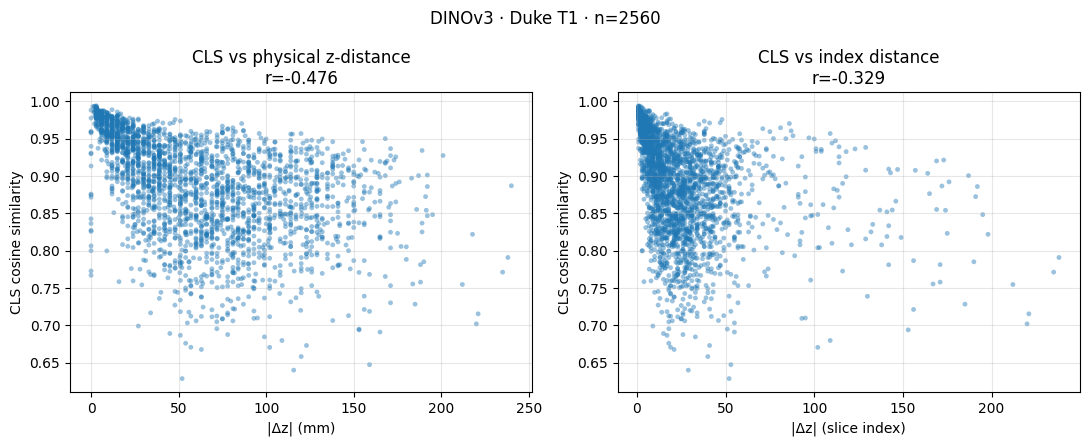

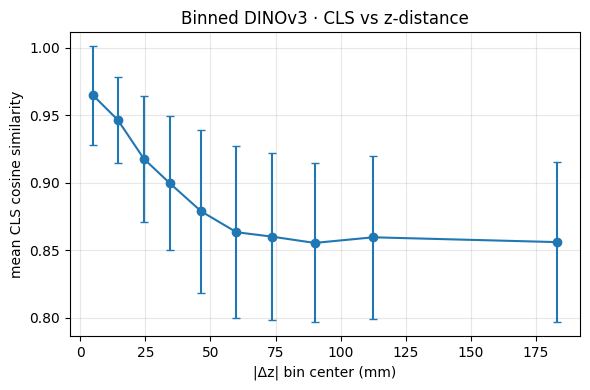

DINOv3 · CLS bin centers (mm): [  5.   14.5  24.5  34.5  46.5  60.   73.5  90.  112.5 183. ]
DINOv3 · CLS bin counts: [250, 262, 251, 205, 311, 229, 251, 270, 271, 260]


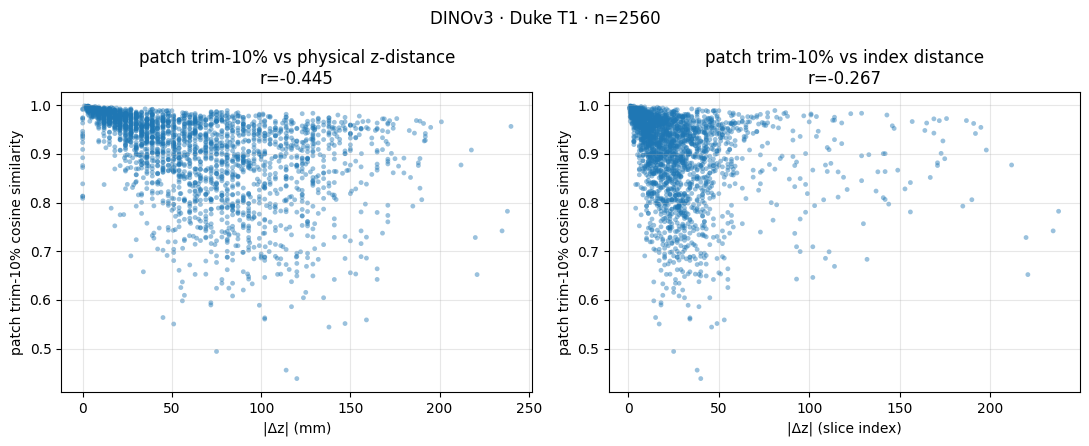

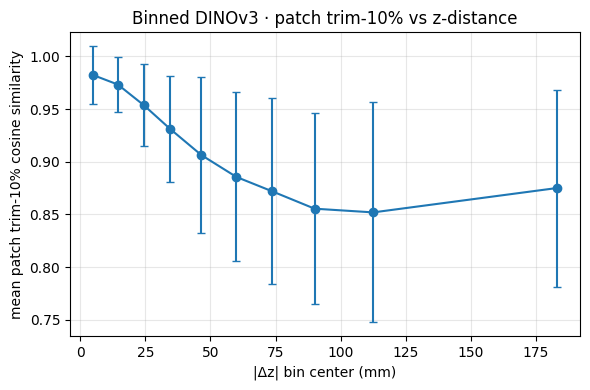

DINOv3 · patch trim-10% bin centers (mm): [  5.   14.5  24.5  34.5  46.5  60.   73.5  90.  112.5 183. ]
DINOv3 · patch trim-10% bin counts: [250, 262, 251, 205, 311, 229, 251, 270, 271, 260]


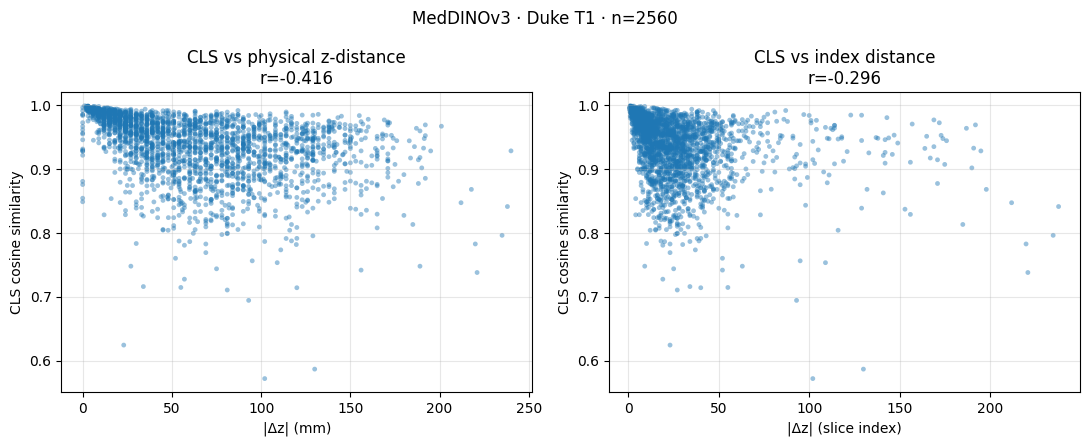

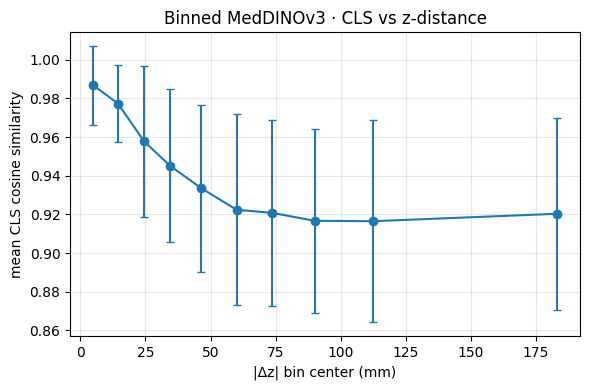

MedDINOv3 · CLS bin centers (mm): [  5.   14.5  24.5  34.5  46.5  60.   73.5  90.  112.5 183. ]
MedDINOv3 · CLS bin counts: [250, 262, 251, 205, 311, 229, 251, 270, 271, 260]


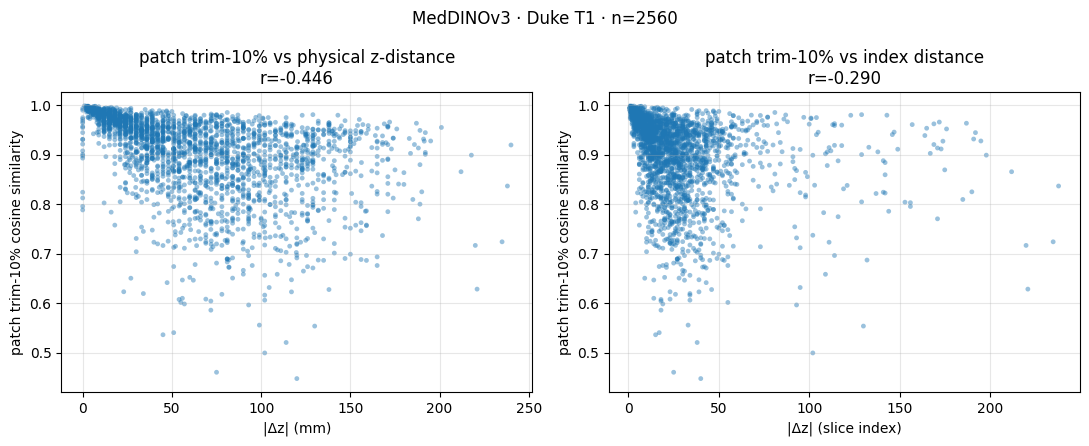

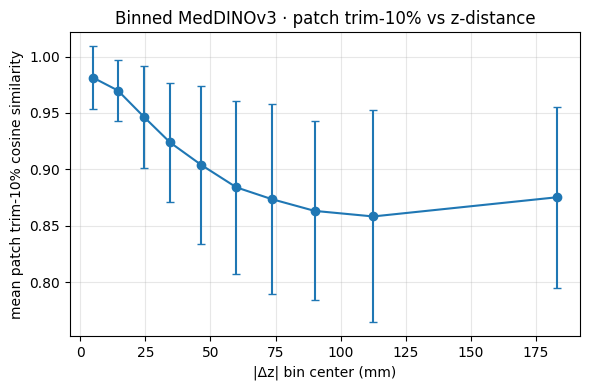

MedDINOv3 · patch trim-10% bin centers (mm): [  5.   14.5  24.5  34.5  46.5  60.   73.5  90.  112.5 183. ]
MedDINOv3 · patch trim-10% bin counts: [250, 262, 251, 205, 311, 229, 251, 270, 271, 260]


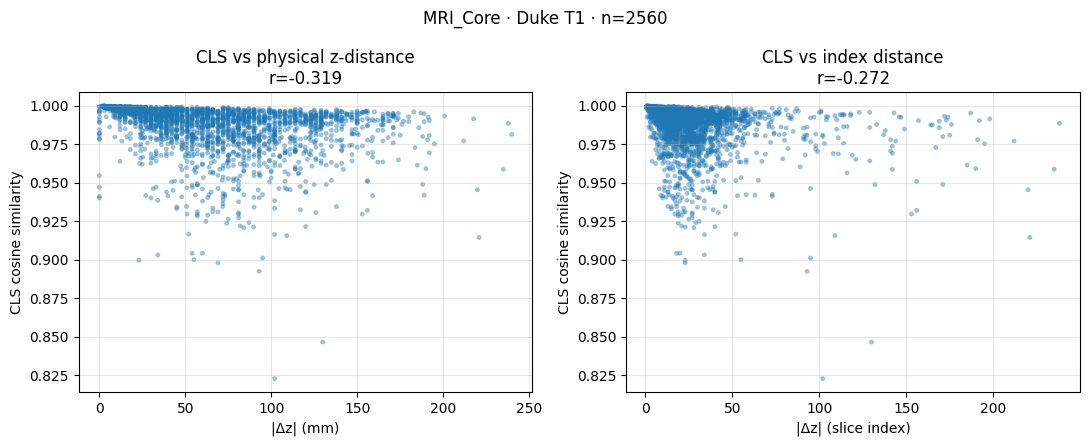

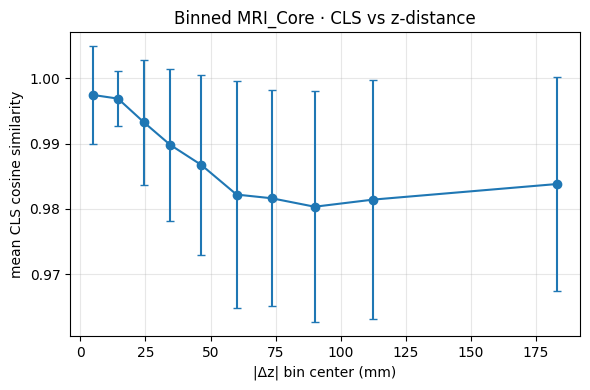

MRI_Core · CLS bin centers (mm): [  5.   14.5  24.5  34.5  46.5  60.   73.5  90.  112.5 183. ]
MRI_Core · CLS bin counts: [250, 262, 251, 205, 311, 229, 251, 270, 271, 260]


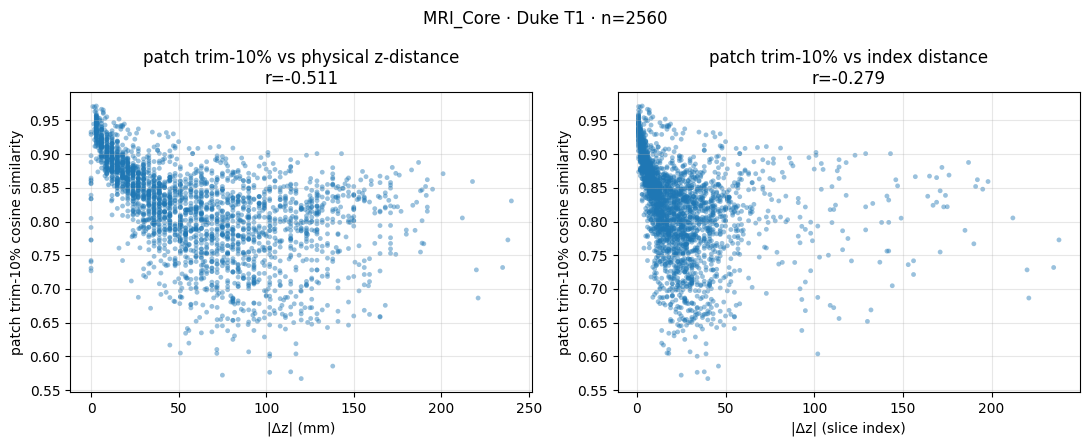

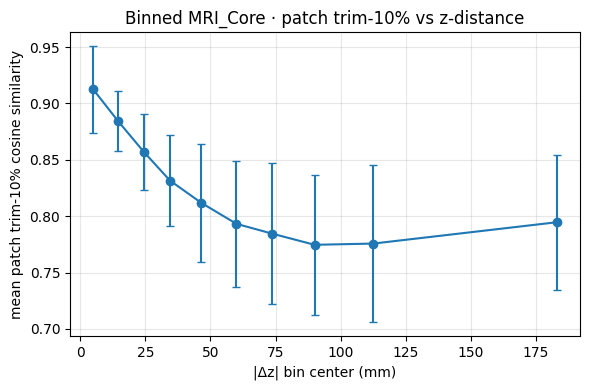

MRI_Core · patch trim-10% bin centers (mm): [  5.   14.5  24.5  34.5  46.5  60.   73.5  90.  112.5 183. ]
MRI_Core · patch trim-10% bin counts: [250, 262, 251, 205, 311, 229, 251, 270, 271, 260]


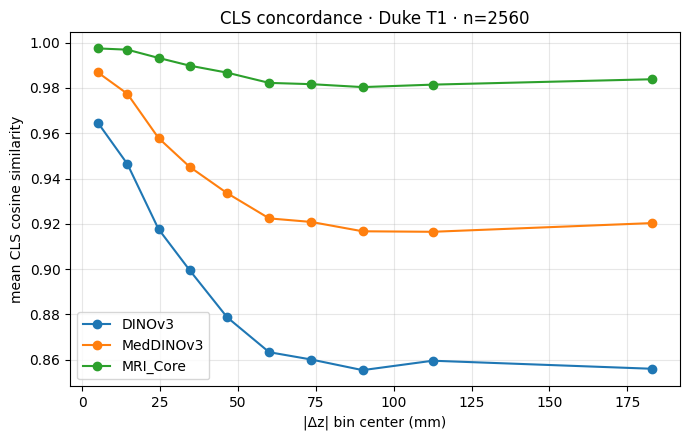

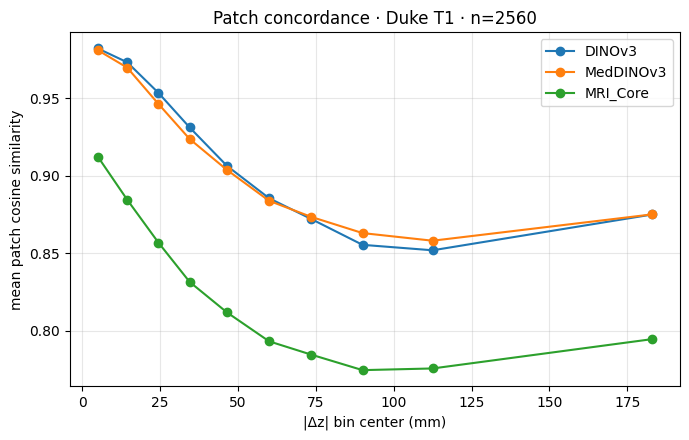

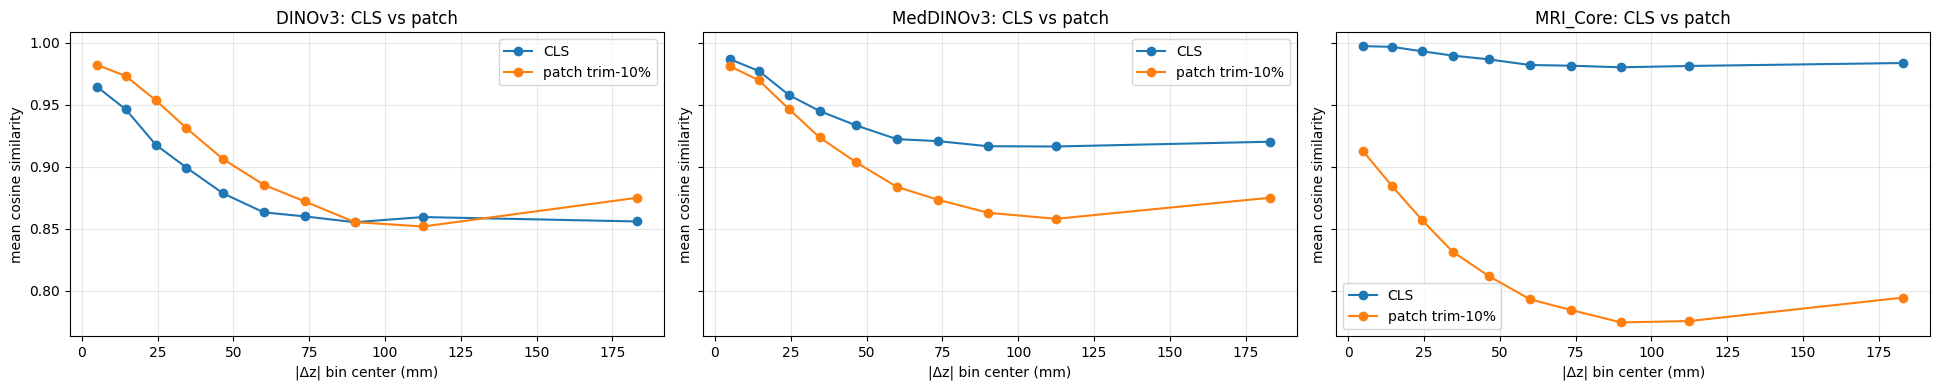

In [37]:
def plot_similarity_vs_distance(
    sim: np.ndarray,
    *,
    model_name: str,
    metric_name: str,
    corr_mm: float,
    corr_idx: float,
    n_bins: int = 10,
):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    axes[0].scatter(z_mm, sim, s=12, alpha=0.45, edgecolors="none")
    axes[0].set_xlabel("|Δz| (mm)")
    axes[0].set_ylabel(f"{metric_name} cosine similarity")
    axes[0].set_title(f"{metric_name} vs physical z-distance\nr={corr_mm:+.3f}")
    axes[0].grid(True, alpha=0.3)

    axes[1].scatter(z_idx, sim, s=12, alpha=0.45, edgecolors="none")
    axes[1].set_xlabel("|Δz| (slice index)")
    axes[1].set_ylabel(f"{metric_name} cosine similarity")
    axes[1].set_title(f"{metric_name} vs index distance\nr={corr_idx:+.3f}")
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(f"{model_name} · Duke {SCAN} · n={len(z_mm)}")
    plt.tight_layout()
    plt.show()

    edges = np.unique(np.quantile(z_mm, np.linspace(0, 1, n_bins + 1)))
    centers, means, stds, counts = [], [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (z_mm >= lo) & (z_mm <= hi) if hi == edges[-1] else (z_mm >= lo) & (z_mm < hi)
        if mask.sum() == 0:
            continue
        centers.append(0.5 * (lo + hi))
        means.append(sim[mask].mean())
        stds.append(sim[mask].std())
        counts.append(int(mask.sum()))

    centers = np.asarray(centers)
    means = np.asarray(means)
    stds = np.asarray(stds)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.errorbar(centers, means, yerr=stds, fmt="o-", capsize=3)
    ax.set_xlabel("|Δz| bin center (mm)")
    ax.set_ylabel(f"mean {metric_name} cosine similarity")
    ax.set_title(f"Binned {model_name} · {metric_name} vs z-distance")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"{model_name} · {metric_name} bin centers (mm):", np.round(centers, 1))
    print(f"{model_name} · {metric_name} bin counts:", counts)
    return centers, means, counts


def _binned_means(sim: np.ndarray, edges: np.ndarray):
    centers, means = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (z_mm >= lo) & (z_mm <= hi) if hi == edges[-1] else (z_mm >= lo) & (z_mm < hi)
        if mask.sum() == 0:
            continue
        centers.append(0.5 * (lo + hi))
        means.append(sim[mask].mean())
    return np.asarray(centers), np.asarray(means)


# Per-model scatter + binned plots
for model_name, res in all_results.items():
    cls_corr_mm, cls_corr_idx = corrs[model_name]["cls"]
    _ = plot_similarity_vs_distance(
        res["cls_sim"],
        model_name=model_name,
        metric_name="CLS",
        corr_mm=cls_corr_mm,
        corr_idx=cls_corr_idx,
    )
    if corrs[model_name]["patch"] is not None:
        patch_corr_mm, patch_corr_idx = corrs[model_name]["patch"]
        _ = plot_similarity_vs_distance(
            res["patch_sim"],
            model_name=model_name,
            metric_name=f"patch trim-{TRIM_PROP:.0%}",
            corr_mm=patch_corr_mm,
            corr_idx=patch_corr_idx,
        )

# Cross-model CLS comparison (all encoders)
n_bins = 10
edges = np.unique(np.quantile(z_mm, np.linspace(0, 1, n_bins + 1)))

fig, ax = plt.subplots(figsize=(7, 4.5))
for model_name, res in all_results.items():
    centers, means = _binned_means(res["cls_sim"], edges)
    ax.plot(centers, means, "o-", label=model_name)
ax.set_xlabel("|Δz| bin center (mm)")
ax.set_ylabel("mean CLS cosine similarity")
ax.set_title(f"CLS concordance · Duke {SCAN} · n={len(z_mm)}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Patch comparison only for models that support it
patch_models = {k: v for k, v in all_results.items() if v.get("do_patch") and v.get("patch_sim") is not None}
if patch_models:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for model_name, res in patch_models.items():
        centers, means = _binned_means(res["patch_sim"], edges)
        ax.plot(centers, means, "o-", label=model_name)
    ax.set_xlabel("|Δz| bin center (mm)")
    ax.set_ylabel("mean patch cosine similarity")
    ax.set_title(f"Patch concordance · Duke {SCAN} · n={len(z_mm)}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Within-model CLS vs patch (skip CLS-only encoders)
patch_capable = [(n, r) for n, r in all_results.items() if r.get("do_patch") and r.get("patch_sim") is not None]
if patch_capable:
    fig, axes = plt.subplots(1, len(patch_capable), figsize=(6.5 * len(patch_capable), 4), sharey=True)
    if len(patch_capable) == 1:
        axes = [axes]
    for ax, (model_name, res) in zip(axes, patch_capable):
        for key, label in (("cls_sim", "CLS"), ("patch_sim", f"patch trim-{TRIM_PROP:.0%}")):
            centers, means = _binned_means(res[key], edges)
            ax.plot(centers, means, "o-", label=label)
        ax.set_xlabel("|Δz| bin center (mm)")
        ax.set_ylabel("mean cosine similarity")
        ax.set_title(f"{model_name}: CLS vs patch")
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Notes / next

- Dataset returns **[0, 1]** tensors; DINOv3 backends ImageNet-normalize at encode time; MRI_Core keeps [0, 1] and upsamples to SAM `image_size` (default 1024).
- MRI_Core `image_encoder` → spatial **patch** features (`[B, C, H, W]` → `[B, H·W, C]`); CLS = mean over patches; patch score uses the same aligned-patch trimmed mean as DINOv3.
- `collect_all_models` scores the **same** pair indices with each encoder.
- Change `SCAN` / `N_VOLUMES` / `PAIRS_PER_VOLUME` as needed; MRI_Core uses a smaller default batch size.

In [38]:
all_results

{'DINOv3': {'z_mm': array([ 47.88,  27.  , 126.  , ...,   8.  ,   0.  ,  24.  ],
        shape=(2560,), dtype=float32),
  'z_idx': array([12.,  9., 42., ...,  4., 13.,  8.], shape=(2560,), dtype=float32),
  'cls_sim': array([0.9486473 , 0.95483756, 0.8641039 , ..., 0.95392287, 0.8065951 ,
         0.9464158 ], shape=(2560,), dtype=float32),
  'do_patch': True,
  'patch_sim': array([0.9198321 , 0.9810484 , 0.68668795, ..., 0.98274213, 0.81243205,
         0.98301196], shape=(2560,), dtype=float32)},
 'MedDINOv3': {'z_mm': array([ 47.88,  27.  , 126.  , ...,   8.  ,   0.  ,  24.  ],
        shape=(2560,), dtype=float32),
  'z_idx': array([12.,  9., 42., ...,  4., 13.,  8.], shape=(2560,), dtype=float32),
  'cls_sim': array([0.9604    , 0.97480667, 0.8328246 , ..., 0.993206  , 0.87601006,
         0.98967767], shape=(2560,), dtype=float32),
  'do_patch': True,
  'patch_sim': array([0.891223  , 0.96810424, 0.6737817 , ..., 0.98471344, 0.8123656 ,
         0.9811554 ], shape=(2560,), dtype=

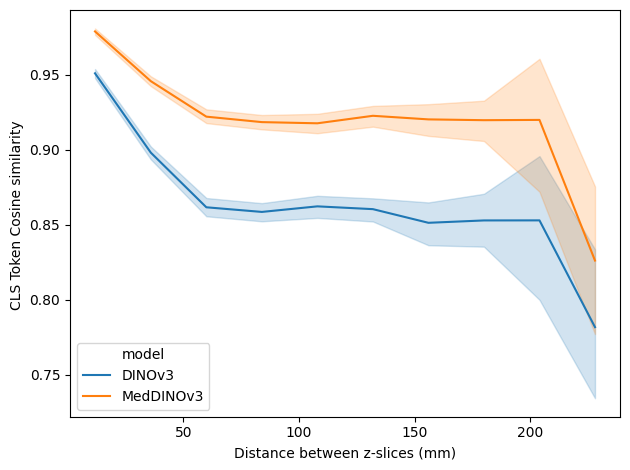

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.DataFrame(columns=['model', 'z_mm', 'cls_sim', 'patch_sim'])

n = len(all_results['DINOv3']['z_mm'])

df['model'] = (["DINOv3"] * n) + (["MedDINOv3"] * n)
df['z_mm'] = np.concatenate([all_results['DINOv3']['z_mm'], all_results['MedDINOv3']['z_mm']])
df['cls_sim'] = np.concatenate([all_results['DINOv3']['cls_sim'], all_results['MedDINOv3']['cls_sim']])
df['patch_sim'] = np.concatenate([all_results['DINOv3']['patch_sim'], all_results['MedDINOv3']['patch_sim']])


df["z_mm_bin"] = pd.cut(df["z_mm"], bins=10)

fig, ax = plt.subplots(tight_layout=True)

sns.lineplot(data=df, x=df["z_mm_bin"].apply(lambda i: i.mid), y="cls_sim", hue='model', ax=ax,errorbar='ci', estimator='mean')

ax.set_xlabel("Distance between z-slices (mm)")
ax.set_ylabel("CLS Token Cosine similarity ")
plt.show()